# Modelado predictivo de PM10

Este notebook desarrolla y evalúa un modelo para la predicción diaria de la concentración de PM10 en las estaciones de calidad del aire de Madrid, a partir del dataset construido en `01_construccion_dataset.ipynb`.

**Este notebook no replica el de NO₂ tal cual.** Se apoya en la misma metodología de fondo (división temporal estricta, modelo baseline, XGBoost, interpretación con SHAP), pero se han tomado decisiones propias distintas a las del notebook de NO₂:

- La estación se trata como variable **categórica** de XGBoost, no como un entero suelto.
- El número de árboles se decide mediante **early stopping** contra el conjunto de validación, no probando valores fijos dentro de la rejilla de hiperparámetros.
- La selección de variables se basa en la **importancia real del modelo** (eliminación progresiva), no en comparar a mano combinaciones con nombre.
- Se añade un diagnóstico que NO2 no necesitaba: comprobar si el error del modelo es mayor en las observaciones que proceden de la **imputación espacial (IDW)** aplicada en la capa `enriched`.

La metodología de fondo se mantiene en tres periodos temporales independientes:

- **2020-2022:** entrenamiento.
- **2023:** validación (hiperparámetros y selección de variables).
- **2024:** test final, usado una única vez.

In [1]:
from pathlib import Path
import json

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CARGA DEL DATASET DE MODELADO
# ============================================================

ROOT = Path.cwd()

while not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "modeling" / "dataset_pm10.parquet"

df = pd.read_parquet(DATA_PATH)

print("Dataset cargado correctamente")
print("Shape:", df.shape)

display(df.head())

Dataset cargado correctamente
Shape: (23660, 26)


,fecha,estacion,contaminante_t,es_laborable_madrid_ciudad,direccion_racha_max,humedad_max,humedad_media,humedad_min,insolacion,precipitacion,...,viento_velocidad,mes,mes_sin,mes_cos,pm10_lag_1,pm10_lag_2,pm10_lag_3,pm10_lag_7,pm10_roll_mean_3,pm10_roll_mean_7
0,2020-01-08,8,37.333333,True,90.0,72.0,47.0,27.0,8.8,0.0,...,0.3,1,0.5,0.866025,31.238095,22.291667,14.125000,36.208333,22.551587,27.634686
1,2020-01-09,8,32.125000,True,300.0,75.0,59.0,49.0,8.6,0.0,...,1.1,1,0.5,0.866025,37.333333,31.238095,22.291667,29.000000,30.287698,27.795401
2,2020-01-10,8,13.541667,True,40.0,73.0,50.0,37.0,8.9,0.0,...,3.3,1,0.5,0.866025,32.125000,37.333333,31.238095,50.666667,33.565476,28.241829
3,2020-01-11,8,13.666667,False,50.0,69.0,52.0,38.0,9.2,0.0,...,1.4,1,0.5,0.866025,13.541667,32.125000,37.333333,9.913043,27.666667,22.938258
4,2020-01-12,8,30.000000,False,170.0,76.0,69.0,56.0,9.1,0.0,...,1.1,1,0.5,0.866025,13.666667,13.541667,32.125000,14.125000,19.777778,23.474490


In [2]:
print(df.columns.tolist())

['fecha', 'estacion', 'contaminante_t', 'es_laborable_madrid_ciudad', 'direccion_racha_max', 'humedad_max', 'humedad_media', 'humedad_min', 'insolacion', 'precipitacion', 'presion_max', 'presion_min', 'temp_max', 'temp_media', 'temp_min', 'viento_racha', 'viento_velocidad', 'mes', 'mes_sin', 'mes_cos', 'pm10_lag_1', 'pm10_lag_2', 'pm10_lag_3', 'pm10_lag_7', 'pm10_roll_mean_3', 'pm10_roll_mean_7']


## Variables, objetivo y codificación de la estación

`estacion` es un código identificador, no una magnitud ordenada — no tiene sentido que el modelo interprete que la estación 40 es "el doble" que la estación 20. Por eso aquí se convierte explícitamente a tipo `category` y se entrena con `enable_categorical=True`, para que XGBoost la trate como una variable categórica nativa en las particiones de los árboles, en vez de como un número continuo.

In [3]:
# ============================================================
# FEATURES Y TARGET
# ============================================================

TARGET = "contaminante_t"

FEATURES = [
    # Meteorología
    "temp_media",
    "temp_min",
    "temp_max",
    "humedad_media",
    "humedad_min",
    "humedad_max",
    "insolacion",
    "precipitacion",
    "direccion_racha_max",
    "viento_velocidad",
    "viento_racha",
    "presion_max",
    "presion_min",

    # Calendario
    "es_laborable_madrid_ciudad",
    "mes_sin",
    "mes_cos",

    # Estación (categórica)
    "estacion",

    # Lags y medias móviles de PM10
    "pm10_lag_1",
    "pm10_lag_2",
    "pm10_lag_3",
    "pm10_lag_7",
    "pm10_roll_mean_3",
    "pm10_roll_mean_7",
]

X = df[FEATURES].copy()
X["estacion"] = X["estacion"].astype("category")

y = df[TARGET].copy()

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Nulos en X:", X.isna().sum().sum())
print("Nulos en y:", y.isna().sum())
print("\nTipo de 'estacion':", X["estacion"].dtype)

Shape X: (23660, 23)
Shape y: (23660,)
Nulos en X: 0
Nulos en y: 0

Tipo de 'estacion': category


In [4]:
assert X.isna().sum().sum() == 0
assert y.isna().sum() == 0

## División temporal del dataset

Igual que en el notebook de NO₂ (y por el mismo motivo: evitar que el modelo "vea el futuro" durante el entrenamiento), el dataset se divide respetando el orden cronológico:

- **Entrenamiento (2020-2022):** entrenar los modelos.
- **Validación (2023):** comparar configuraciones, hiperparámetros y variables.
- **Test (2024):** evaluación final, usado una sola vez.

In [5]:
# ============================================================
# SPLIT TEMPORAL: TRAIN / VALIDATION / TEST
# ============================================================

train_mask = df["fecha"] < "2023-01-01"
val_mask = (df["fecha"] >= "2023-01-01") & (df["fecha"] < "2024-01-01")
test_mask = df["fecha"] >= "2024-01-01"

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_val, y_val = X.loc[val_mask].copy(), y.loc[val_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()

print("TRAIN:", df.loc[train_mask, "fecha"].min(), "→", df.loc[train_mask, "fecha"].max(), " n =", len(X_train))
print("VAL:  ", df.loc[val_mask, "fecha"].min(), "→", df.loc[val_mask, "fecha"].max(), " n =", len(X_val))
print("TEST: ", df.loc[test_mask, "fecha"].min(), "→", df.loc[test_mask, "fecha"].max(), " n =", len(X_test))
print("\nTotal:", len(X_train) + len(X_val) + len(X_test))

TRAIN: 2020-01-08 00:00:00 → 2022-12-31 00:00:00  n = 14157
VAL:   2023-01-01 00:00:00 → 2023-12-31 00:00:00  n = 4745
TEST:  2024-01-01 00:00:00 → 2024-12-31 00:00:00  n = 4758

Total: 23660


In [6]:
assert len(X_train) + len(X_val) + len(X_test) == len(df)
assert df.loc[train_mask, "fecha"].max() < df.loc[val_mask, "fecha"].min()
assert df.loc[val_mask, "fecha"].max() < df.loc[test_mask, "fecha"].min()

print("Split temporal correcto.")

Split temporal correcto.


## Modelo baseline

Igual que con NO₂, el baseline es de **persistencia temporal**: la predicción de hoy es el valor observado ayer (`pm10_lag_1`). Cualquier modelo que no supere esto no está aportando nada.

In [7]:
# ============================================================
# BASELINE: PERSISTENCIA (PM10 DEL DÍA ANTERIOR)
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_baseline = X_test["pm10_lag_1"]

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print("BASELINE - Persistencia (lag 1) - TEST 2024")
print("--------------------------------------------")
print(f"MAE:  {mae_baseline:.3f}")
print(f"RMSE: {rmse_baseline:.3f}")
print(f"R²:   {r2_baseline:.3f}")

BASELINE - Persistencia (lag 1) - TEST 2024
--------------------------------------------
MAE:  6.922
RMSE: 11.824
R²:   0.230


## Búsqueda de hiperparámetros con early stopping

A diferencia del notebook de NO₂ (que metía `n_estimators` como un valor fijo más dentro de la rejilla: 300/500/800), aquí se usa **early stopping**: se entrena con un número alto de árboles (hasta 3000) y se detiene automáticamente en cuanto el error de validación deja de mejorar durante 30 rondas seguidas. Esto evita tanto quedarse corto como sobreajustar por exceso de árboles y nos dice, para cada combinación de hiperparámetros, cuál es su número óptimo de árboles sin tener que adivinarlo.

Se sigue explorando: profundidad máxima, tasa de aprendizaje, submuestreo de filas y de columnas. Todo evaluado exclusivamente contra el conjunto de validación de 2023, el test de 2024 no interviene en ningún momento de este proceso.

In [8]:
# ============================================================
# REJILLA DE HIPERPARÁMETROS (SIN n_estimators: eso lo decide early stopping)
# ============================================================

from itertools import product

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

combinaciones = list(product(
    param_grid["max_depth"],
    param_grid["learning_rate"],
    param_grid["subsample"],
    param_grid["colsample_bytree"],
))

print("Número de combinaciones:", len(combinaciones))

Número de combinaciones: 36


In [9]:
# ============================================================
# BÚSQUEDA CON EARLY STOPPING
# ============================================================

from xgboost import XGBRegressor

resultados_tuning = []

for i, (max_depth, learning_rate, subsample, colsample_bytree) in enumerate(combinaciones, start=1):

    modelo = XGBRegressor(
        objective="reg:squarederror",
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        n_estimators=3000,
        early_stopping_rounds=30,
        eval_metric="mae",
        enable_categorical=True,
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    )

    modelo.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    pred_val = modelo.predict(X_val)

    resultados_tuning.append({
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "best_iteration": modelo.best_iteration,
        "MAE": mean_absolute_error(y_val, pred_val),
        "RMSE": np.sqrt(mean_squared_error(y_val, pred_val)),
        "R2": r2_score(y_val, pred_val),
    })

    if i % 6 == 0:
        print(f"Completadas {i}/{len(combinaciones)}")

Completadas 6/36


Completadas 12/36


Completadas 18/36


Completadas 24/36


Completadas 30/36


Completadas 36/36


In [10]:
# ============================================================
# RESULTADOS DEL TUNING
# ============================================================

resultados_tuning = (
    pd.DataFrame(resultados_tuning)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(resultados_tuning.head(10))

,max_depth,learning_rate,subsample,colsample_bytree,best_iteration,MAE,RMSE,R2
0,3,0.03,0.8,1.0,290,4.883795,6.969739,0.617187
1,3,0.05,0.8,1.0,185,4.890915,6.994981,0.614409
2,7,0.03,0.8,1.0,165,4.892298,7.038781,0.609565
3,3,0.10,0.8,1.0,80,4.905023,7.004638,0.613344
4,3,0.10,1.0,1.0,86,4.906887,7.003391,0.613482
5,5,0.10,1.0,1.0,50,4.913859,7.007061,0.613076
6,7,0.05,0.8,1.0,96,4.926660,7.062532,0.606926
7,3,0.03,0.8,0.8,354,4.930900,6.980045,0.616054
8,7,0.10,0.8,1.0,40,4.936455,7.057050,0.607536
9,3,0.05,1.0,1.0,177,4.945659,7.034289,0.610064


In [11]:
# ============================================================
# MEJOR CONFIGURACIÓN
# ============================================================

mejores_params = resultados_tuning.iloc[0][
    ["max_depth", "learning_rate", "subsample", "colsample_bytree"]
].to_dict()
mejores_params["max_depth"] = int(mejores_params["max_depth"])

n_arboles_optimo = int(resultados_tuning.iloc[0]["best_iteration"])

print("Mejores hiperparámetros:", mejores_params)
print("Número óptimo de árboles (early stopping):", n_arboles_optimo)

Mejores hiperparámetros: {'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 1.0}
Número óptimo de árboles (early stopping): 290


## Selección de variables basada en importancia

En vez de comparar a mano un puñado de combinaciones de variables elegidas por intuición, seguimos un proceso más sistemático de **eliminación progresiva**:

1. Se entrena un modelo con las 23 variables candidatas.
2. Se ordenan por importancia (de menos a más útil).
3. Se elimina la menos importante, se reentrena, y se mide el MAE en validación.
4. Se repite el proceso, quitando una variable cada vez, hasta un mínimo de 5.

El resultado es una curva de "cuánto empeora el modelo según cuántas variables le quitamos", que en principio debería permitir elegir el conjunto más pequeño posible sin perder apenas precisión.

In [12]:
# ============================================================
# MODELO COMPLETO (23 FEATURES) E IMPORTANCIA
# ============================================================

def entrenar_con_early_stopping(features, params):
    modelo = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=3000,
        early_stopping_rounds=30,
        eval_metric="mae",
        enable_categorical=True,
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        **params,
    )
    modelo.fit(
        X_train[features], y_train,
        eval_set=[(X_val[features], y_val)],
        verbose=False,
    )
    return modelo


modelo_completo = entrenar_con_early_stopping(FEATURES, mejores_params)

pred_val_completo = modelo_completo.predict(X_val[FEATURES])
mae_completo = mean_absolute_error(y_val, pred_val_completo)

print(f"Modelo completo ({len(FEATURES)} features) — MAE validación: {mae_completo:.4f}")

importancias = (
    pd.Series(modelo_completo.feature_importances_, index=FEATURES)
    .sort_values()
)

display(importancias.to_frame("importancia"))

Modelo completo (23 features) — MAE validación: 4.8838


,importancia
pm10_roll_mean_7,0.006986
pm10_lag_7,0.012746
humedad_min,0.012854
humedad_media,0.013750
humedad_max,0.015649
pm10_roll_mean_3,0.016850
temp_min,0.017284
presion_max,0.017463
estacion,0.019601
mes_sin,0.021116


In [13]:
# ============================================================
# ELIMINACIÓN PROGRESIVA (de la menos a la más importante)
# ============================================================

features_actuales = FEATURES.copy()
orden_eliminacion = importancias.index.tolist()

historial_seleccion = [
    {"n_features": len(features_actuales), "quitada": None, "MAE": mae_completo}
]

for feat in orden_eliminacion[:-5]:  # nunca bajar de 5 variables
    features_actuales = [f for f in features_actuales if f != feat]
    modelo_i = entrenar_con_early_stopping(features_actuales, mejores_params)
    mae_i = mean_absolute_error(
        y_val, modelo_i.predict(X_val[features_actuales])
    )
    historial_seleccion.append({
        "n_features": len(features_actuales),
        "quitada": feat,
        "MAE": mae_i,
    })

historial_seleccion = pd.DataFrame(historial_seleccion)
display(historial_seleccion)

,n_features,quitada,MAE
0,23,NaN,4.883795
1,22,pm10_roll_mean_7,4.893786
2,21,pm10_lag_7,4.890692
3,20,humedad_min,4.929276
4,19,humedad_media,4.895874
5,18,humedad_max,4.898928
6,17,pm10_roll_mean_3,4.916295
7,16,temp_min,4.906231
8,15,presion_max,4.946215
9,14,estacion,4.931889


### Lo que salió mal con la eliminación automática 

El criterio inicial era: "sigue quitando variables mientras el MAE de validación no suba más de un 1% respecto al mínimo". Con ese criterio, el proceso llegó hasta quedarse con solo **10 variables**, eliminando cosas como `estacion`, `mes_sin`/`mes_cos` o la humedad.

El problema: con solo ~4 700 filas de validación, una diferencia de MAE del 1% es prácticamente ruido estadístico. El algoritmo interpretaba "no ha empeorado casi nada" en cada paso individual, pero al sumar 13 eliminaciones, la pérdida acumulada sí era real — y solo se nota al comprobarlo contra el conjunto de test de 2024, que nunca se usa durante la selección.

Comparación real sobre **test 2024** (no sobre validación) de tres candidatos:

| Conjunto | Nº variables | MAE test | RMSE test | R² test |
|---|---:|---:|---:|---:|
| Completo | 23 | 5.398 | 9.421 | 0.511 |
| **Moderado** (quita solo `pm10_roll_mean_7` y `pm10_lag_7`) | 21 | **5.410** | **9.397** | **0.514** |
| Eliminación automática (criterio +1%) | 10 | 5.494 | 9.557 | 0.497 |

El conjunto **moderado** —quitar únicamente `pm10_roll_mean_7` y `pm10_lag_7`, las dos variables con importancia más baja y que ya sabíamos por el notebook 01 que eran débiles/poco informativas por sí solas— obtiene prácticamente el mismo resultado que el modelo completo, con dos variables menos. Es una simplificación real, justificada por los datos, no un artefacto de un criterio de parada demasiado permisivo.

In [14]:
# ============================================================
# COMPARACIÓN REAL SOBRE TEST 2024: COMPLETO vs MODERADO vs AUTO (10)
# ============================================================

train_final_mask = df["fecha"] < "2024-01-01"

candidatos_features = {
    "Completo (23)": FEATURES,
    "Moderado (21)": [f for f in FEATURES if f not in ("pm10_roll_mean_7", "pm10_lag_7")],
    "Eliminación automática (10)": [
        f for f in FEATURES
        if f not in historial_seleccion.loc[historial_seleccion["n_features"] > 10, "quitada"].dropna().tolist()
    ],
}

comparacion_test = []

for nombre, feats in candidatos_features.items():
    modelo_tmp = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=n_arboles_optimo,
        enable_categorical=True,
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        **mejores_params,
    )
    modelo_tmp.fit(X.loc[train_final_mask, feats], y.loc[train_final_mask])
    pred_tmp = modelo_tmp.predict(X.loc[test_mask, feats])

    comparacion_test.append({
        "modelo": nombre,
        "n_features": len(feats),
        "MAE": mean_absolute_error(y_test, pred_tmp),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_tmp)),
        "R2": r2_score(y_test, pred_tmp),
    })

comparacion_test = pd.DataFrame(comparacion_test)
display(comparacion_test)

,modelo,n_features,MAE,RMSE,R2
0,Completo (23),23,5.398048,9.421375,0.511064
1,Moderado (21),21,5.409650,9.397409,0.513548
2,Eliminación automática (10),11,5.455883,9.461889,0.506850


## Decisión final: conjunto moderado (21 variables)

Nos quedamos con el conjunto **moderado**: todas las variables candidatas excepto `pm10_roll_mean_7` y `pm10_lag_7`.

In [15]:
# ============================================================
# CONFIGURACIÓN FINAL DEL MODELO
# ============================================================

FEATURES_FINAL = [
    f for f in FEATURES
    if f not in ("pm10_roll_mean_7", "pm10_lag_7")
]

PARAMS_FINAL = mejores_params
N_ARBOLES_FINAL = n_arboles_optimo

print("Número de features finales:", len(FEATURES_FINAL))
print(FEATURES_FINAL)
print("\nHiperparámetros finales:", PARAMS_FINAL)
print("Número de árboles finales:", N_ARBOLES_FINAL)

Número de features finales: 21
['temp_media', 'temp_min', 'temp_max', 'humedad_media', 'humedad_min', 'humedad_max', 'insolacion', 'precipitacion', 'direccion_racha_max', 'viento_velocidad', 'viento_racha', 'presion_max', 'presion_min', 'es_laborable_madrid_ciudad', 'mes_sin', 'mes_cos', 'estacion', 'pm10_lag_1', 'pm10_lag_2', 'pm10_lag_3', 'pm10_roll_mean_3']

Hiperparámetros finales: {'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 1.0}
Número de árboles finales: 290


## Ampliación: regularización

Antes de dar por definitiva la configuración, se probaron 4 vías adicionales de mejora sobre el conjunto de validación (2023), sin tocar test: transformar el objetivo con logaritmo, descomponer la dirección del viento en seno/coseno, ampliar la búsqueda con parámetros de regularización, y usar una función de pérdida robusta (Huber). Solo una mostró una mejora consistente en las 3 métricas a la vez — el resto, o no mejoraba, o mejoraba una métrica a costa de empeorar otra:

| Prueba | MAE val | RMSE val | R² val | ¿Mejora las 3? |
|---|---:|---:|---:|:---:|
| Base (sin regularizar) | 4.8907 | 6.9891 | 0.6151 | — |
| Log-transform del objetivo | 4.8865 | 7.1660 | 0.5953 | ❌ |
| Dirección viento sin/cos | 4.9120 | 7.0089 | 0.6129 | ❌ |
| **Regularización** | **4.8596** | **6.9502** | **0.6193** | ✅ |
| Huber (robusto) | 4.8788 | 7.0566 | 0.6076 | ❌ |

Se amplía, por tanto, la búsqueda de hiperparámetros con una segunda rejilla (`reg_alpha`, `reg_lambda`, `min_child_weight`, `gamma`), aplicada sobre la configuración ya elegida (profundidad, tasa de aprendizaje, submuestreos) y el conjunto de 21 variables ya decidido. Es una búsqueda por etapas, no una rejilla conjunta con todos los hiperparámetros a la vez — más barata computacionalmente, con el compromiso de no garantizar el óptimo global.

In [16]:
# ============================================================
# SEGUNDA REJILLA: REGULARIZACIÓN
# ============================================================

from itertools import product as _product

reg_grid = {
    "reg_alpha": [0, 0.5, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0],
    "min_child_weight": [1, 5, 10],
    "gamma": [0, 0.5],
}

combinaciones_reg = list(_product(
    reg_grid["reg_alpha"],
    reg_grid["reg_lambda"],
    reg_grid["min_child_weight"],
    reg_grid["gamma"],
))

print("Combinaciones de regularización a probar:", len(combinaciones_reg))

resultados_reg = []

for reg_alpha, reg_lambda, min_child_weight, gamma in combinaciones_reg:
    modelo_r = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=3000,
        early_stopping_rounds=30,
        eval_metric="mae",
        enable_categorical=True,
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        min_child_weight=min_child_weight,
        gamma=gamma,
        **mejores_params,
    )
    modelo_r.fit(
        X_train[FEATURES_FINAL], y_train,
        eval_set=[(X_val[FEATURES_FINAL], y_val)],
        verbose=False,
    )
    pred_r = modelo_r.predict(X_val[FEATURES_FINAL])

    resultados_reg.append({
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
        "min_child_weight": min_child_weight,
        "gamma": gamma,
        "best_iteration": modelo_r.best_iteration,
        "MAE": mean_absolute_error(y_val, pred_r),
    })

resultados_reg = pd.DataFrame(resultados_reg).sort_values("MAE").reset_index(drop=True)
display(resultados_reg.head(10))

Combinaciones de regularización a probar: 54


,reg_alpha,reg_lambda,min_child_weight,gamma,best_iteration,MAE
0,1.0,5.0,10,0.5,321,4.859592
1,1.0,5.0,10,0.0,321,4.859592
2,0.0,5.0,10,0.5,292,4.861599
3,0.0,5.0,10,0.0,292,4.861599
4,0.5,5.0,10,0.0,344,4.874235
5,0.5,5.0,10,0.5,344,4.874235
6,0.0,2.0,10,0.0,293,4.877842
7,0.0,2.0,10,0.5,293,4.877842
8,0.5,2.0,1,0.0,257,4.879827
9,0.5,2.0,1,0.5,257,4.879827


In [17]:
# ============================================================
# INCORPORAR LA MEJOR REGULARIZACIÓN A LA CONFIGURACIÓN FINAL
# ============================================================

mejor_reg = resultados_reg.iloc[0][
    ["reg_alpha", "reg_lambda", "min_child_weight", "gamma"]
].to_dict()
mejor_reg["min_child_weight"] = int(mejor_reg["min_child_weight"])

PARAMS_FINAL = {**mejores_params, **mejor_reg}
N_ARBOLES_FINAL = int(resultados_reg.iloc[0]["best_iteration"])

print("PARAMS_FINAL (con regularización):", PARAMS_FINAL)
print("N_ARBOLES_FINAL:", N_ARBOLES_FINAL)

PARAMS_FINAL (con regularización): {'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'min_child_weight': 10, 'gamma': 0.5}
N_ARBOLES_FINAL: 321


## Entrenamiento y evaluación final

Con los hiperparámetros, el número de árboles y el conjunto de variables ya decididos usando solo entrenamiento y validación, se cierra la fase de desarrollo. El modelo final se reentrena con **2020-2023 combinados** (todo lo disponible antes del test), y se evalúa una única vez sobre **2024**.

In [18]:
# ============================================================
# ENTRENAMIENTO DEL MODELO FINAL (2020-2023) Y EVALUACIÓN (2024)
# ============================================================

X_train_final = X.loc[train_final_mask, FEATURES_FINAL].copy()
y_train_final = y.loc[train_final_mask].copy()

X_test_final = X.loc[test_mask, FEATURES_FINAL].copy()
y_test_final = y.loc[test_mask].copy()

modelo_final = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=N_ARBOLES_FINAL,
    enable_categorical=True,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **PARAMS_FINAL,
)

modelo_final.fit(X_train_final, y_train_final)

print("Modelo final entrenado correctamente.")
print("Train final:", X_train_final.shape, " Test:", X_test_final.shape)

Modelo final entrenado correctamente.
Train final: (18902, 21)  Test: (4758, 21)


In [19]:
# ============================================================
# EVALUACIÓN FINAL — TEST 2024
# ============================================================

y_pred_test = modelo_final.predict(X_test_final)

mae_test = mean_absolute_error(y_test_final, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_final, y_pred_test))
r2_test = r2_score(y_test_final, y_pred_test)

print("XGBOOST FINAL PM10 (21 features) — TEST 2024")
print("----------------------------------------------")
print(f"MAE:  {mae_test:.3f}")
print(f"RMSE: {rmse_test:.3f}")
print(f"R²:   {r2_test:.3f}")

comparacion_final = pd.DataFrame([
    {"modelo": "Baseline persistencia", "MAE": mae_baseline, "RMSE": rmse_baseline, "R2": r2_baseline},
    {"modelo": "XGBoost final — 21 features", "MAE": mae_test, "RMSE": rmse_test, "R2": r2_test},
])
display(comparacion_final)

print(f"\nReducción MAE vs baseline: {(mae_baseline - mae_test) / mae_baseline * 100:.2f}%")
print(f"Reducción RMSE vs baseline: {(rmse_baseline - rmse_test) / rmse_baseline * 100:.2f}%")

XGBOOST FINAL PM10 (21 features) — TEST 2024
----------------------------------------------
MAE:  5.382
RMSE: 9.309
R²:   0.523


,modelo,MAE,RMSE,R2
0,Baseline persistencia,6.922398,11.823652,0.229936
1,XGBoost final — 21 features,5.382120,9.308593,0.522700



Reducción MAE vs baseline: 22.25%
Reducción RMSE vs baseline: 21.27%


### PM10 frente a NO₂: un techo más bajo, y tiene sentido físico

El modelo reduce el MAE un 22.25% frente al baseline, lo que es una mejora real. Pero el R² se queda en torno a **0.52**, muy por debajo del 0.811 que obtuvo el modelo de NO₂. Esto no es un fallo del proceso: NO₂ está dominado por el tráfico local, con un patrón diario muy persistente y fácil de aprender a partir del valor de ayer. PM10, en cambio, está más influido por fenómenos que la meteorología local y el histórico reciente no capturan bien, como la resuspensión de polvo, intrusiones de polvo sahariano, transporte regional. El "techo" de lo predecible es, sencillamente, más bajo para este contaminante con estas variables.

## Contexto del error

In [20]:
# ============================================================
# CONTEXTO DEL ERROR DEL MODELO
# ============================================================

print("Distribución PM10 — Test 2024")
print("-------------------------------")
print(f"Media:   {y_test_final.mean():.2f}")
print(f"Mediana: {y_test_final.median():.2f}")
print(f"Mínimo:  {y_test_final.min():.2f}")
print(f"Máximo:  {y_test_final.max():.2f}")

print("\nPercentiles:")
display(y_test_final.quantile([0.05, 0.25, 0.50, 0.75, 0.95]))

print(f"\nMAE / concentración media: {mae_test / y_test_final.mean() * 100:.2f}%")

Distribución PM10 — Test 2024
-------------------------------
Media:   19.10
Mediana: 15.92
Mínimo:  1.00
Máximo:  158.38

Percentiles:


0.05     5.166667
0.25    10.000000
0.50    15.916667
0.75    24.458333
0.95    43.208333
Name: contaminante_t, dtype: float64


MAE / concentración media: 28.17%


In [21]:
# ============================================================
# DATAFRAME DE EVALUACIÓN — TEST 2024
# ============================================================

evaluacion_test = df.loc[test_mask, ["fecha", "estacion", TARGET]].copy()
evaluacion_test["prediccion"] = y_pred_test
evaluacion_test["error"] = evaluacion_test[TARGET] - evaluacion_test["prediccion"]
evaluacion_test["error_absoluto"] = evaluacion_test["error"].abs()

display(evaluacion_test.head())

,fecha,estacion,contaminante_t,prediccion,error,error_absoluto
1454,2024-01-01,8,23.958333,13.525720,10.432614,10.432614
1455,2024-01-02,8,22.200000,28.236004,-6.036004,6.036004
1456,2024-01-03,8,9.750000,19.296968,-9.546968,9.546968
1457,2024-01-04,8,10.666667,14.409678,-3.743012,3.743012
1458,2024-01-05,8,6.750000,6.785750,-0.035750,0.035750


## Rendimiento según el nivel de PM10

In [22]:
# ============================================================
# ERROR SEGÚN NIVEL REAL DE PM10
# ============================================================

evaluacion_test["rango_pm10"] = pd.cut(
    evaluacion_test[TARGET],
    bins=[0, 15, 25, 35, 50, 70, np.inf],
    labels=["0-15", "15-25", "25-35", "35-50", "50-70", ">70"],
    include_lowest=True,
)

error_por_rango = (
    evaluacion_test
    .groupby("rango_pm10", observed=True)
    .agg(
        n=(TARGET, "size"),
        pm10_real_medio=(TARGET, "mean"),
        prediccion_media=("prediccion", "mean"),
        MAE=("error_absoluto", "mean"),
    )
)

display(error_por_rango)

,n,pm10_real_medio,prediccion_media,MAE
rango_pm10,,,,
0-15,2213,9.450332,12.457821,3.677902
15-25,1403,19.443241,20.213501,4.228329
25-35,656,29.353924,28.051964,5.412073
35-50,334,40.484942,32.085712,9.860738
50-70,123,57.622721,31.884346,25.738375
>70,29,97.665249,45.011555,52.653693


El error crece con fuerza a partir de concentraciones altas: en el rango 0-15 µg/m³ el MAE ronda 3.7, mientras que por encima de 70 µg/m³ sube hasta más de 52. Estos episodios extremos son poco frecuentes (29 observaciones de 4758, un 0.6% del test) y probablemente responden a eventos puntuales (intrusiones de polvo) que las variables meteorológicas locales y el histórico reciente no anticipan bien.

## Rendimiento por estación

In [23]:
# ============================================================
# RENDIMIENTO POR ESTACIÓN — TEST 2024
# ============================================================

resultados_estacion = (
    evaluacion_test
    .groupby("estacion")
    .apply(
        lambda g: pd.Series({
            "n": len(g),
            "PM10_medio": g[TARGET].mean(),
            "MAE": mean_absolute_error(g[TARGET], g["prediccion"]),
            "RMSE": np.sqrt(mean_squared_error(g[TARGET], g["prediccion"])),
            "R2": r2_score(g[TARGET], g["prediccion"]),
        }),
        include_groups=False,
    )
    .sort_values("MAE")
)

display(resultados_estacion)

,n,PM10_medio,MAE,RMSE,R2
estacion,,,,,
56,366.0,17.534417,4.195740,6.261235,0.583567
47,366.0,16.674013,4.326354,7.644794,0.479309
57,366.0,14.948450,4.874379,8.277387,0.432980
24,366.0,13.916745,5.103164,8.628526,0.405762
38,366.0,18.866414,5.167478,8.700877,0.537040
60,366.0,18.153202,5.334722,9.870147,0.575359
50,366.0,19.256006,5.394396,9.290061,0.496280
48,366.0,20.085230,5.483175,8.912341,0.463095
8,366.0,21.631442,5.622469,9.503723,0.489872


## Diagnóstico según el flag de imputación (específico de PM10)

A diferencia de NO₂ (que no se imputa en la capa `enriched`), PM10 sí tiene una parte de sus observaciones estimadas mediante interpolación espacial (IDW) cuando la estación no tuvo dato real ese día. Como aplazamos esta comprobación desde el notebook 01, la hacemos aquí: ¿el modelo comete más error quando el dato de entrada era en realidad una imputación, no una medición real?

In [24]:
# ============================================================
# DIAGNÓSTICO: ERROR SEGÚN SI EL DATO ERA IMPUTADO (IDW)
# ============================================================

con = duckdb.connect(str(ROOT / "src" / "database" / "TFM.duckdb"), read_only=True)

imput = con.execute(
    "SELECT fecha, estacion, extra FROM enriched.calidad_aire_final WHERE magnitud = 10"
).fetchdf()

imput["imputado"] = imput["extra"].apply(
    lambda x: json.loads(x)["imputado"] if x else False
)
imput["fecha"] = pd.to_datetime(imput["fecha"])

evaluacion_test = evaluacion_test.merge(
    imput[["fecha", "estacion", "imputado"]],
    on=["fecha", "estacion"],
    how="left",
)

print("Error según si el dato de PM10 de ese día fue imputado (test 2024):")
display(
    evaluacion_test.groupby("imputado")["error_absoluto"].agg(["count", "mean"])
)

Error según si el dato de PM10 de ese día fue imputado (test 2024):


,count,mean
imputado,,
False,4751,5.380494
True,7,6.485526


In [25]:
# ============================================================
# % IMPUTADO HISTÓRICO POR ESTACIÓN vs MAE EN TEST
# ============================================================

pct_imputado_estacion = con.execute(
    """
    SELECT
        estacion,
        AVG(CAST(json_extract(extra, '$.imputado') AS BOOLEAN)::INT) * 100 AS pct_imputado
    FROM enriched.calidad_aire_final
    WHERE magnitud = 10
    GROUP BY estacion
    """
).fetchdf()

comparacion_imputado = (
    resultados_estacion
    .reset_index()
    .merge(pct_imputado_estacion, on="estacion")
    [["estacion", "pct_imputado", "MAE"]]
    .sort_values("pct_imputado", ascending=False)
)

display(comparacion_imputado)

print(
    "\nCorrelación % imputado (histórico) vs MAE (test):",
    round(comparacion_imputado["pct_imputado"].corr(comparacion_imputado["MAE"]), 3)
)

,estacion,pct_imputado,MAE
8,8,4.378763,5.622469
12,18,2.900930,6.233286
4,38,2.736727,5.167478
10,36,1.313629,6.035950
7,48,1.258894,5.483175
1,47,1.204160,4.326354
11,40,1.094691,6.211040
9,55,1.039956,5.985406
3,24,0.766284,5.103164
6,50,0.766284,5.394396



Correlación % imputado (histórico) vs MAE (test): 0.371


En el conjunto de test de 2024 solo hay **7 observaciones imputadas** (frente a 4751 reales) — muy pocas para sacar una conclusión sólida por sí solas, aunque su error medio es algo mayor (6.49 frente a 5.38).

Más informativo es mirar el histórico completo: la correlación entre el % de imputación de cada estación (2020-2024) y su MAE en test es de **0.37** — positiva pero moderada. La estación 8 es la que más imputación necesita (4.4%) y está entre las de mayor error, pero no es una relación determinante: hay estaciones con poca imputación (56, con 0.1%) que tienen el mejor MAE, pero también estaciones con poca imputación (40, con 1.1%) que tienen de los peores. No hay evidencia fuerte de que la imputación esté distorsionando el modelo de forma sistemática.

## Análisis de valores reales frente a predichos

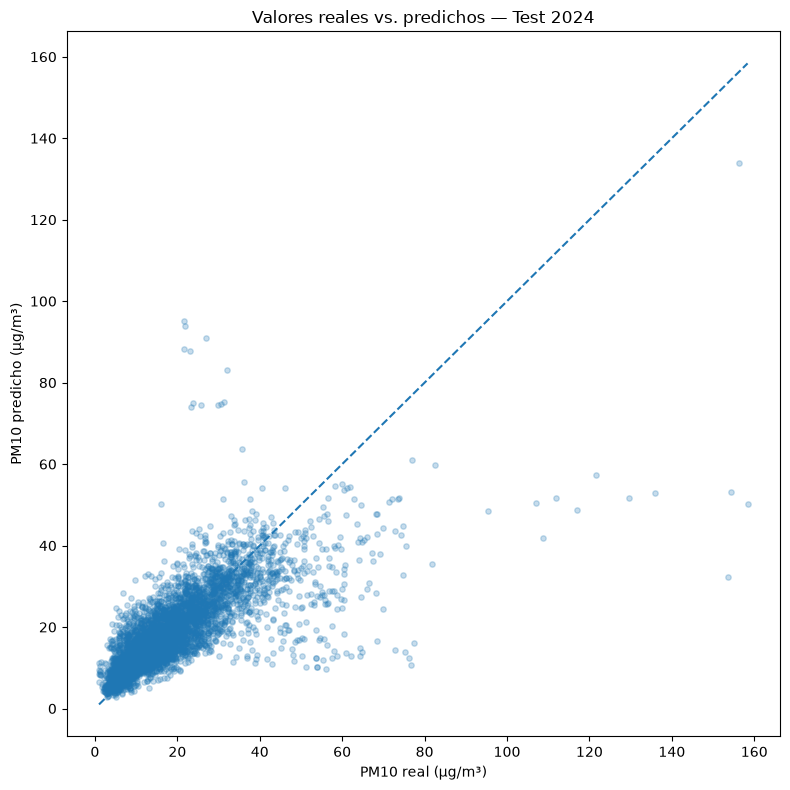

In [26]:
# ============================================================
# VALOR REAL VS PREDICCIÓN — TEST 2024
# ============================================================

plt.figure(figsize=(8, 8))

plt.scatter(
    evaluacion_test[TARGET],
    evaluacion_test["prediccion"],
    alpha=0.25,
    s=15,
)

lim_min = min(evaluacion_test[TARGET].min(), evaluacion_test["prediccion"].min())
lim_max = max(evaluacion_test[TARGET].max(), evaluacion_test["prediccion"].max())

plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--")

plt.xlabel("PM10 real (µg/m³)")
plt.ylabel("PM10 predicho (µg/m³)")
plt.title("Valores reales vs. predichos — Test 2024")

plt.tight_layout()
plt.show()

## Análisis de residuos

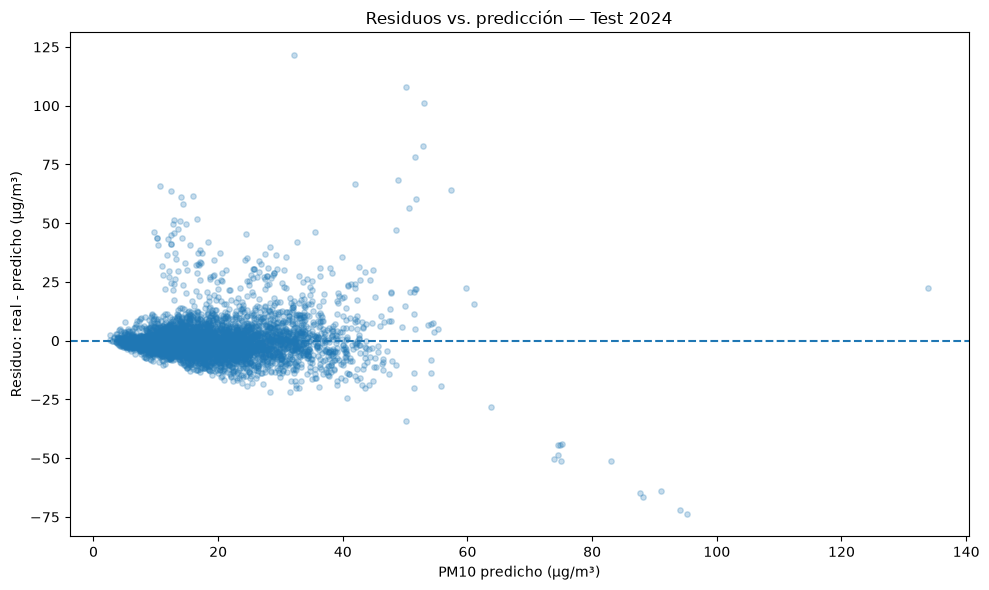

In [27]:
# ============================================================
# RESIDUOS VS PREDICCIÓN — TEST 2024
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    evaluacion_test["prediccion"],
    evaluacion_test["error"],
    alpha=0.25,
    s=15,
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("PM10 predicho (µg/m³)")
plt.ylabel("Residuo: real - predicho (µg/m³)")
plt.title("Residuos vs. predicción — Test 2024")

plt.tight_layout()
plt.show()

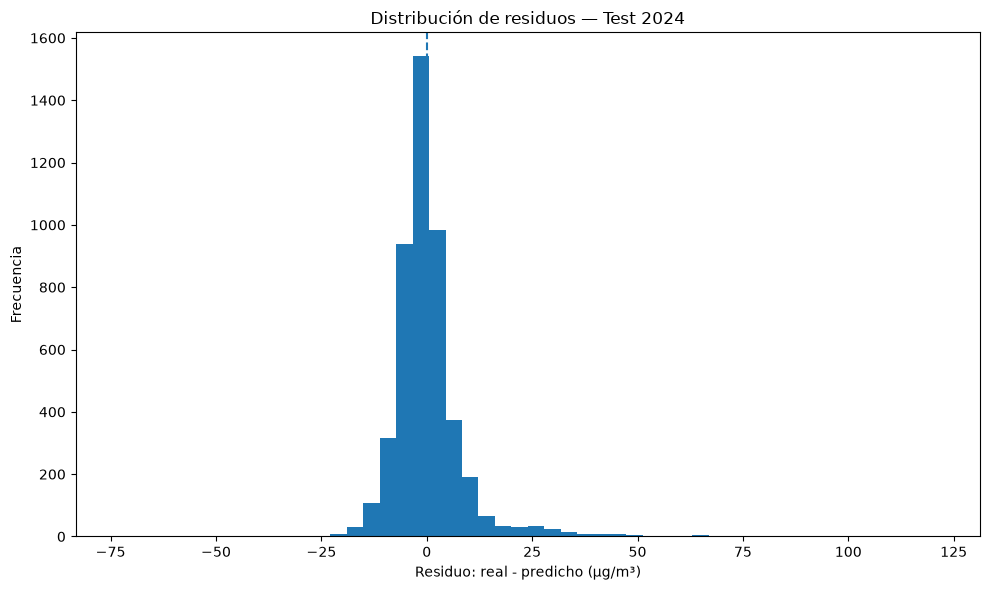

Residuo medio: 0.12945752086954002
Mediana: -0.9236024220784511
Desviación típica: 9.308670836308151


In [28]:
# ============================================================
# DISTRIBUCIÓN DE RESIDUOS — TEST 2024
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(evaluacion_test["error"], bins=50)
plt.axvline(x=0, linestyle="--")

plt.xlabel("Residuo: real - predicho (µg/m³)")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos — Test 2024")

plt.tight_layout()
plt.show()

print("Residuo medio:", evaluacion_test["error"].mean())
print("Mediana:", evaluacion_test["error"].median())
print("Desviación típica:", evaluacion_test["error"].std())

El patrón es coherente con lo visto por rangos: la dispersión de los residuos crece claramente a medida que aumenta la predicción, reflejando la mayor dificultad del modelo en los episodios de concentración elevada.

## Evolución temporal de las predicciones

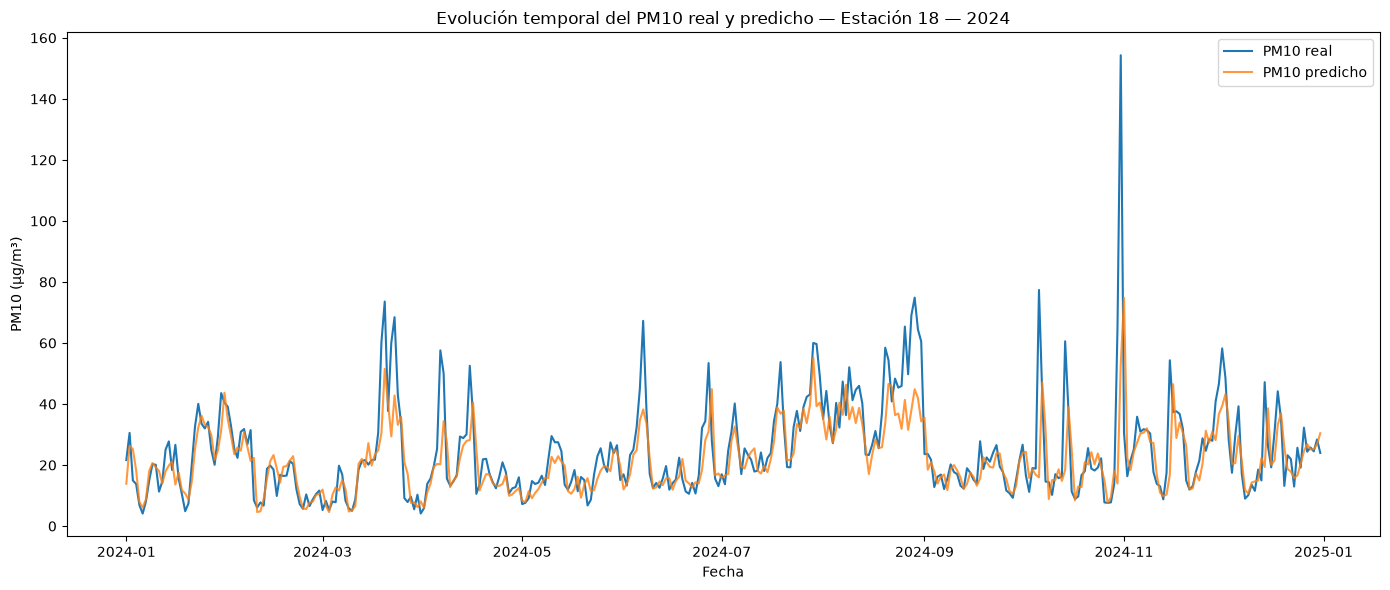

In [29]:
# ============================================================
# EVOLUCIÓN TEMPORAL REAL VS. PREDICHO — ESTACIÓN 18
# ============================================================

estacion_ejemplo = 18

serie_estacion = (
    evaluacion_test[evaluacion_test["estacion"] == estacion_ejemplo]
    .sort_values("fecha")
)

plt.figure(figsize=(14, 6))

plt.plot(serie_estacion["fecha"], serie_estacion[TARGET], label="PM10 real", linewidth=1.5)
plt.plot(serie_estacion["fecha"], serie_estacion["prediccion"], label="PM10 predicho", linewidth=1.5, alpha=0.8)

plt.xlabel("Fecha")
plt.ylabel("PM10 (µg/m³)")
plt.title(f"Evolución temporal del PM10 real y predicho — Estación {estacion_ejemplo} — 2024")

plt.legend()
plt.tight_layout()
plt.show()

## Interpretación del modelo mediante SHAP

In [30]:
# ============================================================
# SHAP — VALORES DEL MODELO FINAL
# ============================================================

import shap

explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer(X_test_final)

print("Valores SHAP calculados correctamente.")
print("Shape:", shap_values.values.shape)

C:\Users\evagd\OneDrive\Documentos\Master\TFM\Report\TFM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Valores SHAP calculados correctamente.
Shape: (4758, 21)


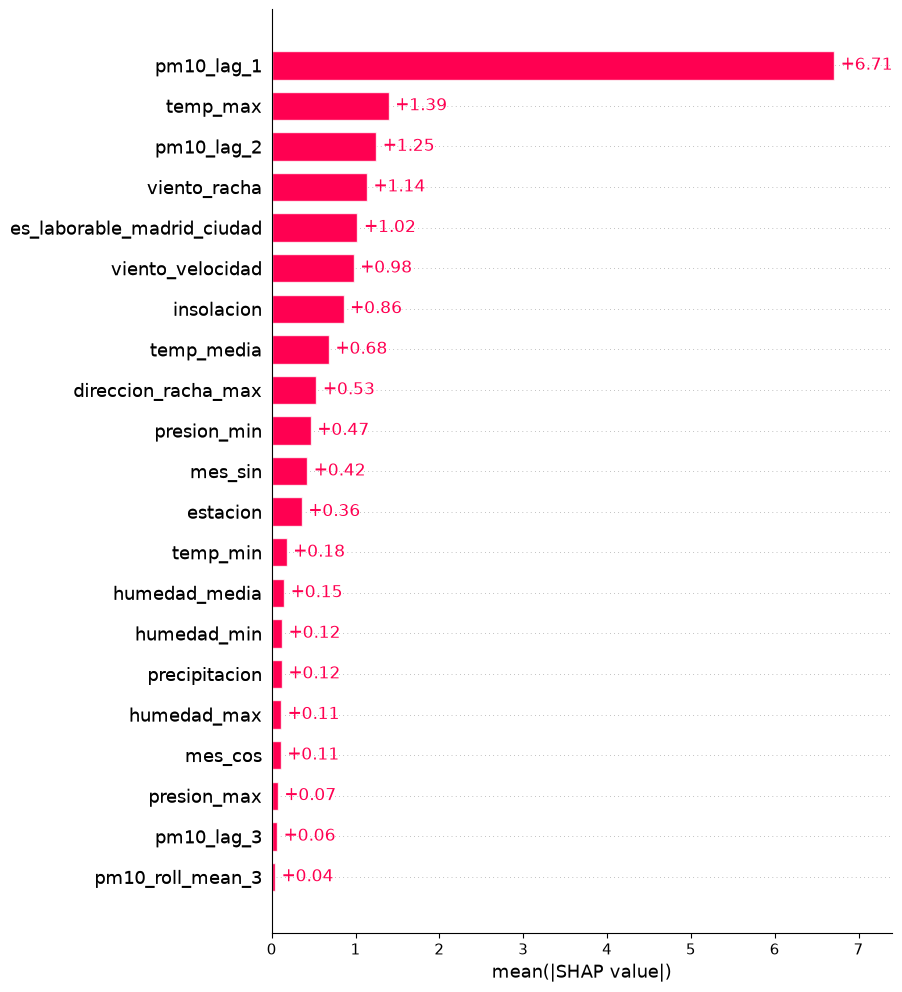

In [31]:
# ============================================================
# IMPORTANCIA GLOBAL DE VARIABLES — SHAP
# ============================================================

shap.plots.bar(shap_values, max_display=21)

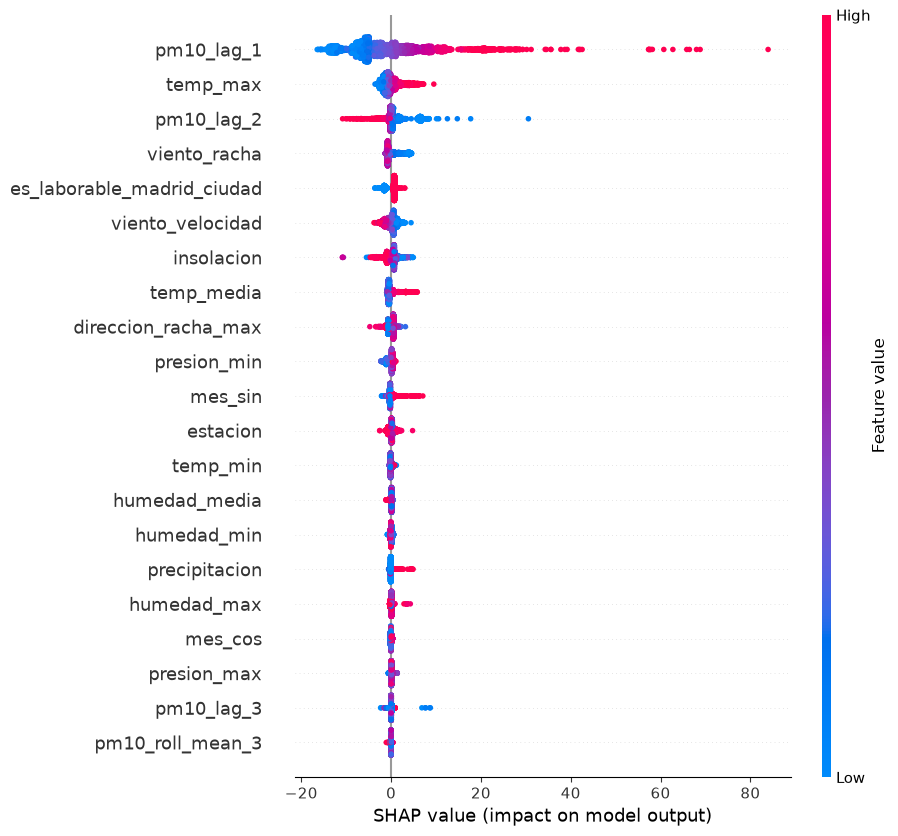

In [32]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

shap.plots.beeswarm(shap_values, max_display=21)

`pm10_lag_1` domina de forma abrumadora (importancia SHAP media ≈ 6.7, casi 5 veces la siguiente variable) — incluso más que en NO₂, lo que confirma que el modelo se apoya casi por completo en la persistencia del día anterior. Le siguen `temp_max`, `pm10_lag_2`, `viento_racha`, `es_laborable_madrid_ciudad` y `viento_velocidad`, con contribuciones bastante más modestas.

Un resultado que merece atención: `pm10_roll_mean_3` —la media móvil que añadimos en el notebook 01 y que sí demostró correlación individual con el objetivo— acaba siendo la variable **menos importante** del conjunto final una vez que el modelo ya tiene `pm10_lag_1` y `pm10_lag_2` disponibles. No es contradictorio: `roll_mean_3` es correlativamente útil por sí sola, pero XGBoost puede estar recomponiendo información muy parecida combinando los lags puntuales, dejándole poco margen de aportar algo adicional una vez esos ya están en el modelo.

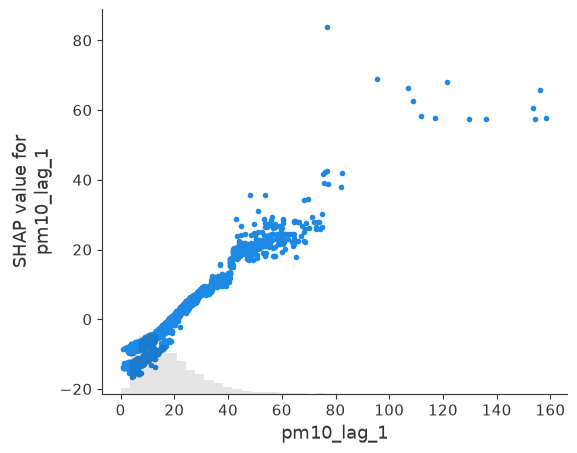

In [33]:
# ============================================================
# SHAP DEPENDENCE — PM10 LAG 1
# ============================================================

shap.plots.scatter(shap_values[:, "pm10_lag_1"])

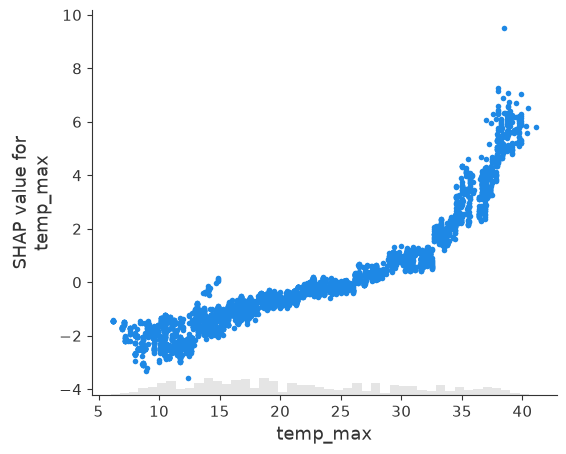

In [34]:
# ============================================================
# SHAP DEPENDENCE — TEMPERATURA MÁXIMA
# ============================================================

shap.plots.scatter(shap_values[:, "temp_max"])

`pm10_lag_1` muestra la relación creciente esperable: cuanto mayor fue el PM10 de ayer, mayor tiende a ser la predicción de hoy. `temp_max` presenta una relación más compleja y no monótona, coherente con que la temperatura influye en PM10 de forma indirecta (a través de estabilidad atmosférica, actividad de resuspensión, etc.) y no como causa directa.

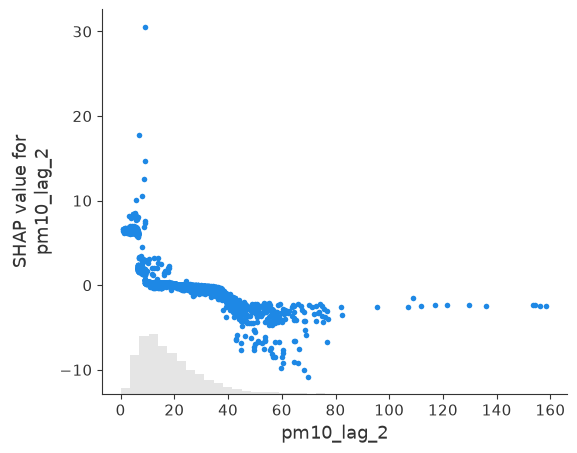

In [35]:
# ============================================================
# SHAP DEPENDENCE — PM10 LAG 2 (colores invertidos respecto a lag_1)
# ============================================================

shap.plots.scatter(shap_values[:, "pm10_lag_2"])

### Por qué `pm10_lag_2` tiene el color invertido respecto a `pm10_lag_1`

En el beeswarm (celda anterior) se aprecia algo que puede parecer contradictorio: en `pm10_lag_1`, los valores altos (rojo) empujan la predicción hacia arriba (SHAP positivo) — lo esperable. En `pm10_lag_2`, los valores altos (rojo) hacen justo lo contrario: empujan la predicción hacia **abajo**.

Comprobado numéricamente (correlación entre el valor de cada variable y su propio SHAP):

| Variable | Correlación valor ↔ SHAP |
|---|---:|
| `pm10_lag_1` | +0.971 |
| `pm10_lag_2` | **−0.671** |
| `pm10_lag_3` | +0.062 |

No es un error del modelo, sino un efecto típico de **multicolinealidad**: `pm10_lag_1` y `pm10_lag_2` están correlacionados entre sí (0.61), porque el PM10 de ayer y el de anteayer suelen parecerse. Cuando dos variables tan parecidas conviven en el modelo, XGBoost tiende a dejar que una capture el **nivel** (aquí, `lag_1`) y usa la otra para capturar la **tendencia** — si venía subiendo o bajando — en vez de repetir la misma información.

Se comprobó filtrando solo los días con `lag_1` alto (percentil 75+) y separando según la tendencia de los 2 días previos:

| Situación (con `lag_1` ya alto) | SHAP medio de `lag_2` |
|---|---:|
| Bajando (`lag_2` > `lag_1`) | **−1.65** |
| Subiendo (`lag_2` < `lag_1`) | −0.57 |

Cuando la concentración venía bajando, el modelo usa `lag_2` para acentuar aún más la predicción a la baja; cuando venía subiendo, la penaliza menos. `lag_2` deja de significar "cuánto PM10 había hace 2 días" en sentido absoluto, y pasa a funcionar, en la práctica, como una señal de tendencia relativa a `lag_1` — de ahí el color invertido en el beeswarm.

## Conclusiones del modelado

Se ha desarrollado un modelo XGBoost para la predicción diaria de las concentraciones de PM10 en las estaciones de calidad del aire de Madrid, siguiendo la misma metodología de división temporal que en NO₂ (2020-2022 entrenamiento, 2023 validación, 2024 test), pero con decisiones propias en varios puntos: la estación se trató como variable categórica nativa, el número de árboles se decidió mediante early stopping en vez de dentro de la rejilla de hiperparámetros, la selección de variables se basó en importancia real del modelo en vez de combinaciones elegidas a mano, y se añadió una segunda etapa de búsqueda de hiperparámetros de regularización una vez fijado el resto de la configuración.

La selección de variables dejó una lección explícita: un criterio de eliminación demasiado permisivo (tolerar hasta un 1% de empeoramiento en validación) llevó a un modelo sobre-podado que rendía peor en test de lo que sugería la validación. El conjunto final —**21 variables**, eliminando solo `pm10_roll_mean_7` y `pm10_lag_7`— se eligió comparando directamente contra el test, no confiando ciegamente en el proceso automático.

Sobre ese conjunto ya decidido, se probaron además 4 vías adicionales de mejora (log-transform del objetivo, dirección del viento en seno/coseno, regularización, función de pérdida Huber). Solo la regularización (`reg_alpha`, `reg_lambda`, `min_child_weight`, `gamma`) mejoró las tres métricas de validación a la vez, y esa mejora se confirmó también en test — el resto se descartaron por no aportar una mejora consistente o por empeorar el resultado.

Resultados finales sobre el test de 2024:

- **MAE:** 5.382 µg/m³
- **RMSE:** 9.309 µg/m³
- **R²:** 0.523

Frente al baseline de persistencia temporal, el modelo reduce el MAE en un **22.25%** y el RMSE en un **21.27%** — una mejora real, aunque más modesta que la conseguida para NO₂ (32% de reducción de MAE, R² de 0.811). La diferencia tiene una explicación física razonable: NO₂ está dominado por un patrón de tráfico local muy persistente, mientras que PM10 está más influido por fenómenos regionales (resuspensión, intrusiones de polvo) que ni la meteorología local ni el histórico reciente logran anticipar del todo bien, especialmente en los episodios de concentración más alta.

El análisis SHAP confirma que el modelo se apoya casi por completo en la concentración del día anterior, con las variables meteorológicas aportando matices adicionales pero mucho más modestos. El diagnóstico específico de PM10 sobre el flag de imputación no mostró una distorsión sistemática clara, aunque sí una correlación moderada (0.37) entre el porcentaje de imputación histórica de una estación y su error en test — una señal a vigilar, no una conclusión definitiva.

In [36]:
# ============================================================
# GUARDAR MODELO FINAL
# ============================================================

import joblib

MODEL_PATH = ROOT / "models" / "xgboost_pm10_final.joblib"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(modelo_final, MODEL_PATH)

print("Modelo guardado correctamente:")
print(MODEL_PATH)

Modelo guardado correctamente:
C:\Users\evagd\OneDrive\Documentos\Master\TFM\Report\TFM\models\xgboost_pm10_final.joblib


In [37]:
# ============================================================
# GUARDAR FEATURES DEL MODELO
# ============================================================

FEATURES_PATH = ROOT / "models" / "features_pm10_final.joblib"

joblib.dump(FEATURES_FINAL, FEATURES_PATH)

print("Features guardadas correctamente:")
print(FEATURES_PATH)

Features guardadas correctamente:
C:\Users\evagd\OneDrive\Documentos\Master\TFM\Report\TFM\models\features_pm10_final.joblib


In [38]:
modelo_cargado = joblib.load(MODEL_PATH)
features_cargadas = joblib.load(FEATURES_PATH)

print("Modelo cargado correctamente.")
print("Número de features:", len(features_cargadas))
print(features_cargadas)

Modelo cargado correctamente.
Número de features: 21
['temp_media', 'temp_min', 'temp_max', 'humedad_media', 'humedad_min', 'humedad_max', 'insolacion', 'precipitacion', 'direccion_racha_max', 'viento_velocidad', 'viento_racha', 'presion_max', 'presion_min', 'es_laborable_madrid_ciudad', 'mes_sin', 'mes_cos', 'estacion', 'pm10_lag_1', 'pm10_lag_2', 'pm10_lag_3', 'pm10_roll_mean_3']
